In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
#print(str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
config_dict = {
    "sim_params": {
        "is2d": 'true',
        "N": 16384 * 16384,
        "nx": 16384,
        "ny": 16384,
        "dx": 8.5e-8,          # 85 nm
        "z_detector": 4.0,     # 探测器位置 4.0 m
        "detector_size": 0.85e-3,       # 探测器 0.85 mm
        "detector_size_y": 0.85e-3,
        "detector_pixel_size_x": 2e-7, # 像素可调
        "detector_pixel_size_y": 2e-7,
        "chunk_size": 2*1024*1024*1024 // 16,
    },
    "use_disk_vector": False,
    "save_final_u_vectors": False,
    "dtype": "c8",
    "multisource": {
        "type": "points",
        "energy_range": [9999, 10001],
        "x_range": [-1e-6, 1e-6],
        "y_range": [-1e-6, 1e-6],
        "z": 0.0,
        "nr_source_points": 1,
        "seed": 1,
    },
    "elements": [
        {
            "type": "sample",
            "z_start": 1.0,            # 样品位于 1.0 m
            "pixel_size_x": 5e-9,      # 样品内部高分辨率
            "pixel_size_y": 5e-9,
            "pixel_size_z": 5e-9,
            "grid_path": "/mnt/d/rave-sim-main/rave-sim-main/grid/100um_half_hollow_millisphere_with_1e-6_with_void_grid.npy",
            "materials": [["H", 1.00]],
            "x_positions": [0],
            "y_positions": [0],
        },
    ],
}

print("N: ", config_dict["sim_params"]["N"])

N:  268435456


In [5]:
sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)

2026-05-09 00:17:49,715 INFO: Setting up simulation


1 1


2026-05-09 00:19:13,674 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260509_001812295747


In [6]:
computed = config.load(Path(sim_path / 'computed.yaml'))

#print("cutoff angles:", computed['cutoff_angles'])
#print("source points:", computed['source_points'])

In [7]:
# Run this in a for loop to simulate all source points or
# alternatively run the source points as individual euler
# jobs
#for i in range(20):
#    multisim.run_single_simulation(sim_path, i, scratch_dir, save_keypoints_path=scratch_dir)
for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
    os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-05-09 00:19:44.999] [info] 3D mode:
[2026-05-09 00:19:45.001] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260509_001812295747/00000000
[2026-05-09 00:19:45.001] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-05-09 00:19:45.001] [info] GPU memory required for wavefield: 2048 MB
[2026-05-09 00:19:45.816] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-05-09 00:19:59.808] [info]   Number of optical elements: 1
[2026-05-09 00:26:50.079] [info] Saved post-sample wavefield to /mnt/d/rave-sim-main/rave-sim-main/notebooks/capsule_test_260508/debug_wave/apply_sample_2d_post_phase_0.npy
[2026-05-09 00:27:23.318] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-05-09 00:27:23.318] [info]   d_detector_output = 0x809000000
[2026-05-09 00:27:23.318] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07
[2026-05-09 00:27:23.318] [info]   current_z=4, dx=8.5e-08, dy=8.5e-08
[20

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [08:10<00:00, 490.64s/it]


In [8]:
wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
print("nr sources loaded:", len(wavefronts))
wavef= [result[0] for result in wavefronts]
wf = np.sum(wavef, axis=0)
print("nr phase steps:", wf.shape[0])
print("nr detector pixels:", wf.shape[1],wf.shape[2])

nr sources loaded: 1
nr phase steps: 1
nr detector pixels: 4250 4250


[[2.33659317e-19 1.11347390e-19 1.95722345e-19 ... 1.18401196e-18
  3.41180027e-19 1.80294432e-19]
 [9.10875329e-20 1.45182528e-19 1.54134922e-19 ... 2.45535950e-19
  1.60377900e-19 1.26360770e-19]
 [2.24285629e-19 2.47385707e-19 1.75188466e-19 ... 2.23375110e-19
  6.63861685e-20 1.58617427e-19]
 ...
 [6.59086242e-19 2.50084617e-19 1.89415610e-19 ... 1.58410774e-18
  2.43053995e-19 2.78465985e-19]
 [3.42324690e-19 2.69973244e-19 1.71077404e-19 ... 4.85043202e-19
  7.12576484e-20 1.79415733e-19]
 [1.30928784e-19 1.98083481e-19 1.66017605e-19 ... 1.33880009e-19
  1.00647104e-19 1.40104569e-19]]


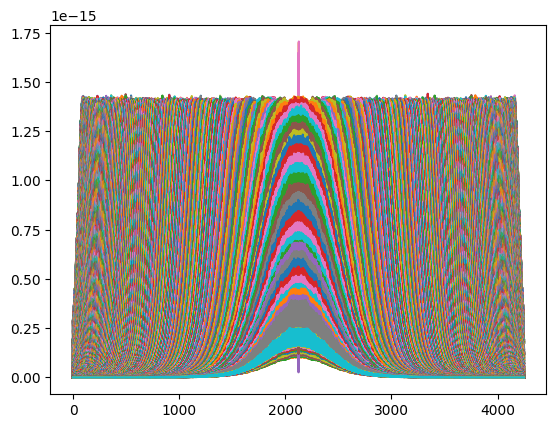

In [9]:
sp = config_dict["sim_params"]
detector_x = util.detector_x_vector(sp["detector_size"], sp["detector_pixel_size_x"])
plt.plot(wf[0])
print(wf[0])
# print(detector_x)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = sim_path / "00000001"
debug_dir = Path.cwd() / "debug_wave"   # 如果仿真中保存了调试波场

# 1. 加载探测器输出
detected_path = output_dir / "detected.npy"
if detected_path.exists():
    detected = np.load(detected_path)
    print(f"detected.npy shape: {detected.shape}")
    print(f"Min: {detected.min()}, Max: {detected.max()}, Mean: {detected.mean()}")
    if detected.max() == 0:
        print("⚠️ detector 输出全为零。")
    else:
        print("✅ detector 输出非零。")
        # 绘制探测器图像
        plt.figure(figsize=(8,6))
        if detected.ndim == 2:
            plt.imshow(detected, cmap='hot', origin='lower')
        else:
            # 多相位步，取第一个
            plt.imshow(detected[0], cmap='hot', origin='lower')
        plt.colorbar(label='Intensity')
        plt.title('Detector image')
        plt.xlabel('x pixel')
        plt.ylabel('y pixel')
        plt.show()
else:
    print(f"❌ 未找到 {detected_path}")
    detected = None

# 2. 加载中间波场并可视化幅度和相位
def plot_wavefield(file_path, title):
    if not file_path.exists():
        print(f"未找到 {file_path}")
        return
    data = np.load(file_path)
    # 复数数组形状可能是 (N,) 或 (ny, nx)
    if data.ndim == 1:
        # 展平的一维数组，需要根据网格尺寸重塑
        nx = config_dict["sim_params"]["nx"]
        ny = config_dict["sim_params"]["ny"]
        data = data.reshape(ny, nx)
    amplitude = np.abs(data)
    phase = np.angle(data)
    print(f"{title}: shape={data.shape}, amplitude min={amplitude.min():.3e}, max={amplitude.max():.3e}, mean={amplitude.mean():.3e}")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
    im1 = ax1.imshow(amplitude, cmap='inferno', origin='lower')
    ax1.set_title(f'{title} amplitude')
    plt.colorbar(im1, ax=ax1)
    im2 = ax2.imshow(phase, cmap='hsv', origin='lower', vmin=-np.pi, vmax=np.pi)
    ax2.set_title(f'{title} phase')
    plt.colorbar(im2, ax=ax2)
    plt.tight_layout()
    plt.show()

❌ 未找到 /mnt/d/rave-sim-main/rave-sim-main/output/2026/05/20260509_001812295747/00000001/detected.npy


In [14]:
from contextlib import redirect_stdout
with open('output_3d_test_void_260509.txt', 'w') as file:
    with redirect_stdout(file):
        for i in range(len(wf[0])):
            print(wf[0][i])

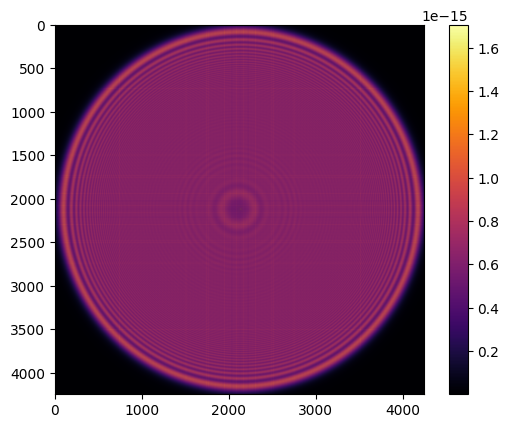

In [15]:
plt.imshow(wf[0],cmap='inferno')
plt.colorbar()
plt.show()

In [ ]:
# 尝试加载各个阶段的波场
wave_after_source = output_dir / "wave_after_source.npy"   # 需在C++中保存
if wave_after_source.exists():
    plot_wavefield(wave_after_source, 'After source propagation')
else:
    # 尝试从 debug_wave 目录加载
    pre_sample = debug_dir / "apply_sample_2d_pre_phase_0.npy"
    if pre_sample.exists():
        plot_wavefield(pre_sample, 'Before sample (pre)')
    else:
        print("未找到 wave_after_source.npy 或 debug_wave/apply_sample_2d_pre_phase_0.npy，请在 C++ 中添加 save_vector 调用。")

post_sample = debug_dir / "apply_sample_2d_post_phase_0.npy"
if post_sample.exists():
    plot_wavefield(post_sample, 'After sample (post)')

# 3. 如果有多个相位步，可以显示各相位步的探测器总和
if detected is not None and detected.ndim == 3:
    phase_intensities = detected.sum(axis=(1,2))
    plt.figure()
    plt.plot(phase_intensities, marker='o')
    plt.xlabel('Phase step')
    plt.ylabel('Total intensity')
    plt.title('Total intensity per phase step')
    plt.grid(True)
    plt.show()

## History

To see the interference pattern in empty space, we can record slices throughout the simulation and then plot them. `run_single_simulation` takes an optional argument `history_dz` defining the resolution with which we record the history.

Note that the history is not necessarily recorded with a constant z-spacing. Inside gratings and samples, one slice is recorded for every step. The history also records a list of z-coordinates at which the slices were recorded, which we can use for plotting.

In [ ]:
multisim.run_single_simulation(sim_path, 1, scratch_dir, save_keypoints_path=None, history_dz=0.02)

In [ ]:
# Path to the directory for the source with index 1
source_dir = multisim.get_sub_dir(sim_path, 1)

hist_x = np.load(source_dir / "history_x.npy")
hist_z = np.load(source_dir / "history_z.npy")
hist = np.load(source_dir / "history.npy")
plt.pcolormesh(
    hist_z,
    hist_x,
    hist,
    cmap="Greys_r",
    vmin=0,
    vmax=1e-6,
    shading="nearest",
)
plt.xlabel("z (m)")
plt.ylabel("x (m)")